# 4_wilcox_DE.R

In [1]:
wd="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/seurat_obj"
setwd(wd)

output_dic="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/seurat_obj/cell_type/"

In [2]:
library(Seurat)
library(stringr)
library(dplyr)
library(tibble)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# Only need to be run in the first time

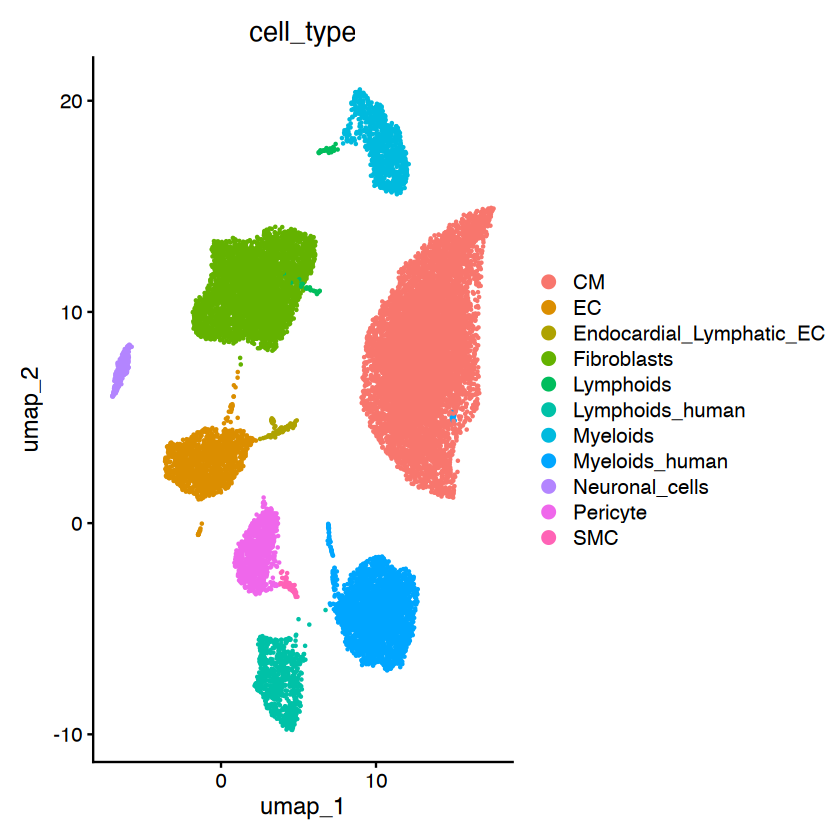

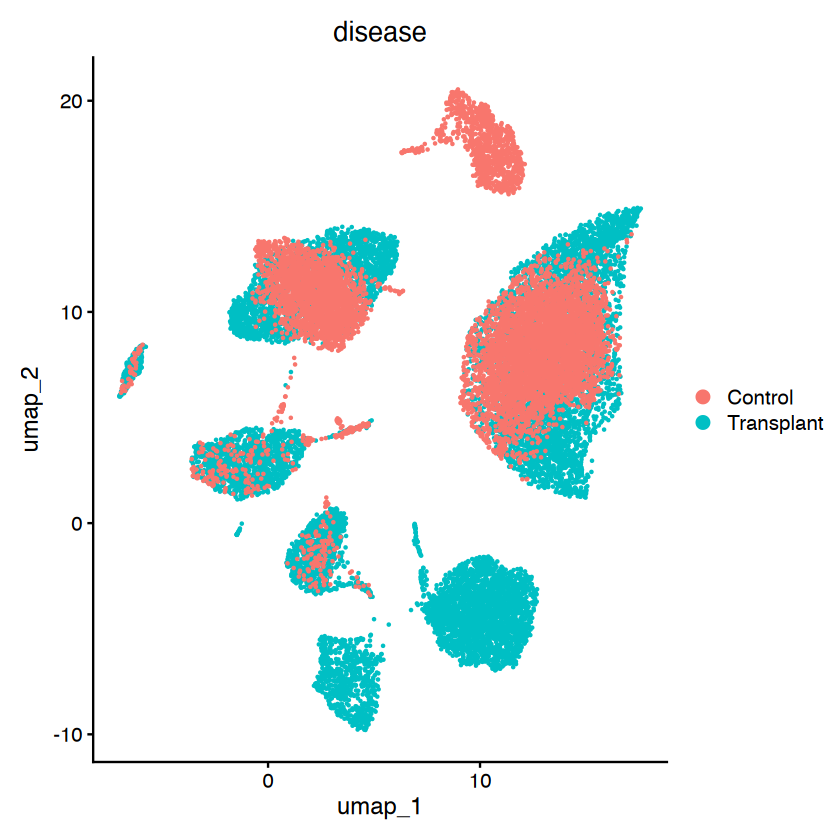

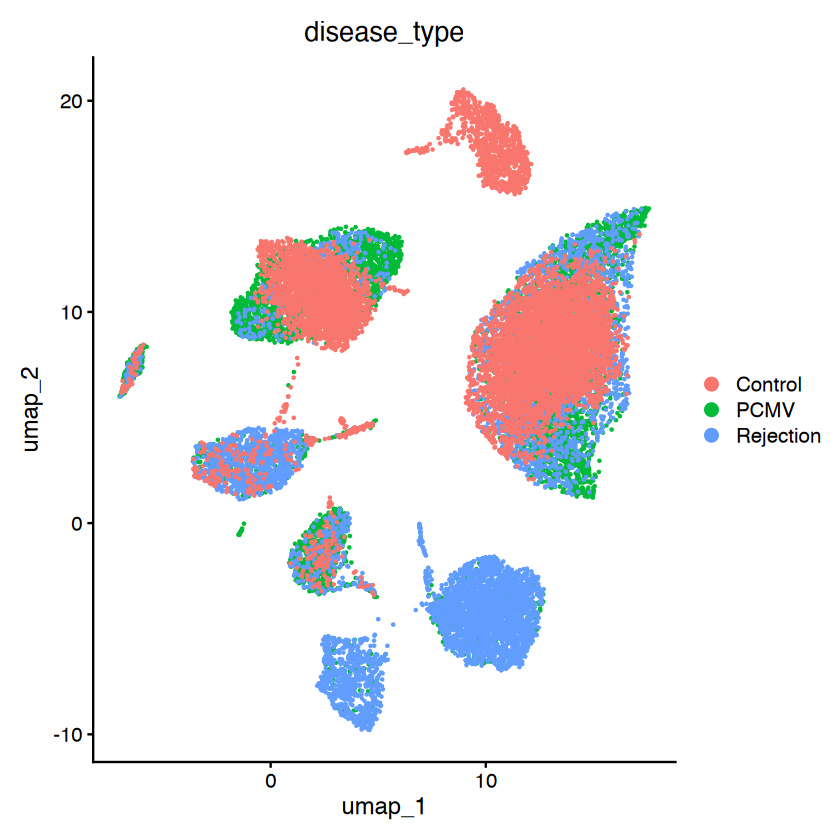

In [3]:
#-------Step 0: Preprocess seurat object-------
#read in seurat object
seurat_obj=readRDS("Humanxeno_annot.rds")
meta_table=read.csv("/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/final_meta_table/meta_table_for_coding.csv", stringsAsFactors = FALSE)

meta_table=meta_table %>% distinct(sample, .keep_all = TRUE)

#change meta information
meta_data=seurat_obj@meta.data %>%
  as.data.frame() %>%
  rownames_to_column("cell_id") %>%
  left_join(meta_table, by = "sample") %>%
  column_to_rownames("cell_id") %>%
  as.data.frame(check.names = FALSE)  
seurat_obj@meta.data=meta_data

DimPlot(seurat_obj, group.by="cell_type")
DimPlot(seurat_obj, group.by="disease")
DimPlot(seurat_obj, group.by="disease_type")

In [4]:
#-------Step 1: Seperate each cell type seurat object-------
celltype=unique(seurat_obj@meta.data$cell_type)
for (i in 1:length(celltype))
{
    print(celltype[i])
    seurat_obj_celltype=seurat_obj[ ,which(seurat_obj@meta.data$cell_type == celltype[i])]
    saveRDS(seurat_obj_celltype, file=paste0("./cell_type/", celltype[i], ".rds"))
}

[1] "CM"
[1] "Fibroblasts"
[1] "EC"
[1] "Endocardial_Lymphatic_EC"
[1] "Myeloids_human"
[1] "Pericyte"
[1] "Lymphoids_human"
[1] "Neuronal_cells"
[1] "Myeloids"
[1] "SMC"
[1] "Lymphoids"


# 1. Transplanted vs control

In [5]:
#-------Step 2: Run DE analysis-------
setwd("/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/seurat_obj/cell_type/")
output_dic="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/results/wilcox_de_humanxeno/"

#cell type information
celltype = c(
  "CM",
  "Fibroblasts",
  "EC",
  "Endocardial_Lymphatic_EC",
  "Pericyte",
  "Neuronal_cells",
  "SMC"
)


for (i in 1:length(celltype))
{
	seurat_obj_celltype=readRDS(file=paste0(celltype[i], ".rds"))
	seurat_obj_celltype=JoinLayers(seurat_obj_celltype, assay="RNA")
	seurat_obj_celltype=NormalizeData(seurat_obj_celltype, normalization.method="LogNormalize", scale.factor=10000)

	#print basic information
  print(i)
	print(table(seurat_obj_celltype@meta.data$cell_type))
	print(table(seurat_obj_celltype@meta.data$disease))

	#conduct de
	disease_group=colnames(seurat_obj_celltype)[which(seurat_obj_celltype@meta.data$disease=="Transplant")]
	control_group=colnames(seurat_obj_celltype)[which(seurat_obj_celltype@meta.data$disease=="Control")]
  if (length(disease_group)>3 & length(control_group)>3)
  {
    de=FindMarkers(seurat_obj_celltype, ident.1=disease_group, ident.2=control_group, test.use="wilcox",
      assay="RNA",
      slot="data",
      logfc.threshold=0.1, min.pct=0.01)
    
    write.table(de, file=paste0(output_dic, celltype[i],"_wilcox_de.csv"),sep="\t",quote=F)
  }
}

Normalizing layer: counts



[1] 1

  CM 
8661 

   Control Transplant 
      4559       4102 


Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Normalizing layer: counts



[1] 2

Fibroblasts 
       4513 

   Control Transplant 
      2297       2216 


Normalizing layer: counts



...

[1] 5

Pericyte 
     859 

   Control Transplant 
       113        746 


Normalizing layer: counts



[1] 6

Neuronal_cells 
           195 

   Control Transplant 
        47        148 


Normalizing layer: counts



[1] 7

SMC 
 68 

   Control Transplant 
        10         58 


# 2. PCMV vs control tissue

In [6]:
#-------Step 2: Run DE analysis-------
setwd("/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/seurat_obj/cell_type/")
output_dic="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/results/wilcox_de_humanxeno/"

#cell type information
celltype = c(
  "CM",
  "Fibroblasts",
  "EC",
  "Endocardial_Lymphatic_EC",
  "Pericyte",
  "Neuronal_cells",
  "SMC"
)


for (i in 1:length(celltype))
{
	seurat_obj_celltype=readRDS(file=paste0(celltype[i], ".rds"))
	seurat_obj_celltype=JoinLayers(seurat_obj_celltype, assay="RNA")
	seurat_obj_celltype=NormalizeData(seurat_obj_celltype, normalization.method="LogNormalize", scale.factor=10000)

	#print basic information
  print(i)
	print(table(seurat_obj_celltype@meta.data$cell_type))
	print(table(seurat_obj_celltype@meta.data$disease_type))

	#conduct de
	disease_group=colnames(seurat_obj_celltype)[which(seurat_obj_celltype@meta.data$disease_type=="PCMV")]
	control_group=colnames(seurat_obj_celltype)[which(seurat_obj_celltype@meta.data$disease_type=="Control")]
  if (length(disease_group)>3 & length(control_group)>3)
  {
    de=FindMarkers(seurat_obj_celltype, ident.1=disease_group, ident.2=control_group, test.use="wilcox",
      assay="RNA",
      slot="data",
      logfc.threshold=0.1, min.pct=0.01)
    
    write.table(de, file=paste0(output_dic, celltype[i],"_wilcox_de.csv"),sep="\t",quote=F)
  }
}

Normalizing layer: counts



[1] 1

  CM 
8661 

  Control      PCMV Rejection 
     4559      2411      1691 


Normalizing layer: counts



[1] 2

Fibroblasts 
       4513 

  Control      PCMV Rejection 
     2297      1835       381 


Normalizing layer: counts



...

[1] 5

Pericyte 
     859 

  Control      PCMV Rejection 
      113       531       215 


Normalizing layer: counts



[1] 6

Neuronal_cells 
           195 

  Control      PCMV Rejection 
       47       110        38 


Normalizing layer: counts



[1] 7

SMC 
 68 

  Control      PCMV Rejection 
       10        23        35 


# 3. Rejection vs control biopsy

In [7]:
#-------Step 2: Run DE analysis-------
setwd("/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/seurat_obj/cell_type/")
output_dic="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/results/wilcox_de_humanxeno/"

#cell type information
celltype = c(
  "CM",
  "Fibroblasts",
  "EC",
  "Endocardial_Lymphatic_EC",
  "Pericyte",
  "Neuronal_cells",
  "SMC"
)


for (i in 1:length(celltype))
{
	seurat_obj_celltype=readRDS(file=paste0(celltype[i], ".rds"))
	seurat_obj_celltype=JoinLayers(seurat_obj_celltype, assay="RNA")
	seurat_obj_celltype=NormalizeData(seurat_obj_celltype, normalization.method="LogNormalize", scale.factor=10000)

	#print basic information
  print(i)
	print(table(seurat_obj_celltype@meta.data$cell_type))
	print(table(seurat_obj_celltype@meta.data$disease_type))

	#conduct de
	disease_group=colnames(seurat_obj_celltype)[which(seurat_obj_celltype@meta.data$disease_type=="Rejection")]
	control_group=colnames(seurat_obj_celltype)[which(seurat_obj_celltype@meta.data$disease_type=="Control")]
  if (length(disease_group)>3 & length(control_group)>3)
  {
    de=FindMarkers(seurat_obj_celltype, ident.1=disease_group, ident.2=control_group, test.use="wilcox",
      assay="RNA",
      slot="data",
      logfc.threshold=0.1, min.pct=0.01)
    
    write.table(de, file=paste0(output_dic, celltype[i],"_wilcox_de.csv"),sep="\t",quote=F)
  }
}

Normalizing layer: counts



[1] 1

  CM 
8661 

  Control      PCMV Rejection 
     4559      2411      1691 


Normalizing layer: counts



[1] 2

Fibroblasts 
       4513 

  Control      PCMV Rejection 
     2297      1835       381 


Normalizing layer: counts



...

[1] 5

Pericyte 
     859 

  Control      PCMV Rejection 
      113       531       215 


Normalizing layer: counts



[1] 6

Neuronal_cells 
           195 

  Control      PCMV Rejection 
       47       110        38 


Normalizing layer: counts



[1] 7

SMC 
 68 

  Control      PCMV Rejection 
       10        23        35 


# 4. PCMV vs rejection

In [8]:
#-------Step 2: Run DE analysis-------
setwd("/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/seurat_obj/cell_type/")
output_dic="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/results/wilcox_de_humanxeno/"

#cell type information
celltype = c(
"CM",
"Fibroblasts",
"EC",
"Endocardial_Lymphatic_EC",
"Myeloids_human",
"Pericyte",
"Lymphoids_human",
"Neuronal_cells",
"Myeloids",
"SMC",
"Lymphoids"
)


for (i in 1:length(celltype))
{
	seurat_obj_celltype=readRDS(file=paste0(celltype[i], ".rds"))
	seurat_obj_celltype=JoinLayers(seurat_obj_celltype, assay="RNA")
	seurat_obj_celltype=NormalizeData(seurat_obj_celltype, normalization.method="LogNormalize", scale.factor=10000)

	#print basic information
  print(i)
	print(table(seurat_obj_celltype@meta.data$cell_type))
	print(table(seurat_obj_celltype@meta.data$disease_type))

	#conduct de
	disease_group=colnames(seurat_obj_celltype)[which(seurat_obj_celltype@meta.data$disease_type=="PCMV")]
	control_group=colnames(seurat_obj_celltype)[which(seurat_obj_celltype@meta.data$disease_type=="Rejection")]
  if (length(disease_group)>3 & length(control_group)>3)
  {
    de=FindMarkers(seurat_obj_celltype, ident.1=disease_group, ident.2=control_group, test.use="wilcox",
      assay="RNA",
      slot="data",
      logfc.threshold=0.1, min.pct=0.01)
    
    write.table(de, file=paste0(output_dic, celltype[i],"_wilcox_de.csv"),sep="\t",quote=F)
  }
}

Normalizing layer: counts



[1] 1

  CM 
8661 

  Control      PCMV Rejection 
     4559      2411      1691 


Normalizing layer: counts



[1] 2

Fibroblasts 
       4513 

  Control      PCMV Rejection 
     2297      1835       381 


Normalizing layer: counts



...

[1] 9

Myeloids 
     917 

Control    PCMV 
    915       2 


Normalizing layer: counts



[1] 10

SMC 
 68 

  Control      PCMV Rejection 
       10        23        35 


Normalizing layer: counts



[1] 11

Lymphoids 
       72 

Control 
     72 
